<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/IMPLEMENTASI_BACKPROPAGATION_MANUAL_DENGAN_SATU_HIDDEN_LAYER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mengunduh dataset dari sumber resmi...

Daftar file dalam arsip ZIP:
['y_amazon-google-large.csv']

File CSV yang digunakan: y_amazon-google-large.csv

Dataset berhasil dimuat.
Ukuran dataset awal: (3055000, 4)

Kolom dataset:
['Unnamed: 0', 'ds', 'y', 'unique_id']

Contoh lima baris pertama:


,Unnamed: 0,ds,y,unique_id
0,0,2020-01-01 08:00:00,6.0,0
1,1,2020-01-01 09:00:00,0.0,0
2,2,2020-01-01 10:00:00,4.0,0
3,3,2020-01-01 11:00:00,8.0,0
4,4,2020-01-01 12:00:00,4.0,0



Jumlah data setelah praproses: 3055000
Jumlah kategori unique_id: 235

ID kategori/lokasi terpilih: 0
Jumlah observasi pada ID terpilih: 13000


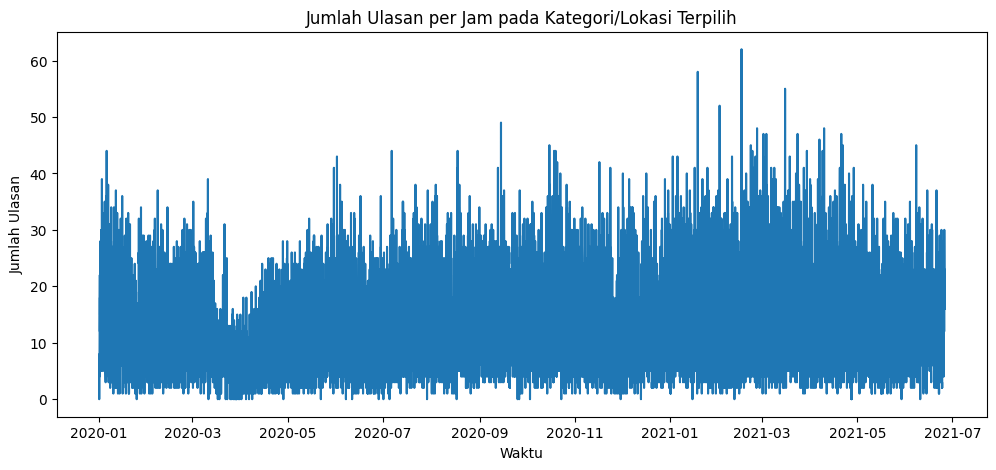

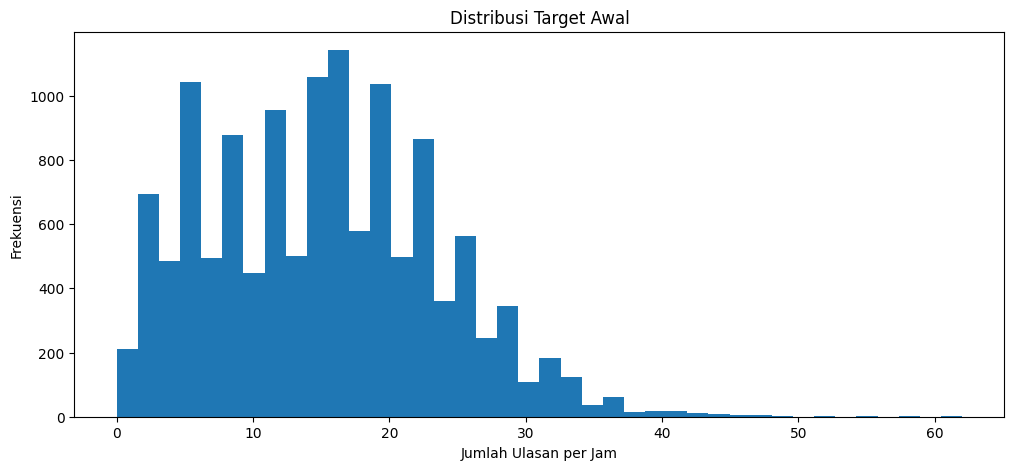


Ukuran data setelah rekayasa fitur:
Jumlah sampel : 12832
Jumlah fitur  : 9

Early stopping aktif pada epoch ke-58

Tabel evaluasi model:


,Data,MAE,RMSE,sMAPE (%),R2
0,Train,10.397606,12.880138,105.844439,-1.672055
1,Validasi,13.832176,22.153175,72.756960,-4.283830
2,Test,12.410833,23.486031,93.186311,-6.917273


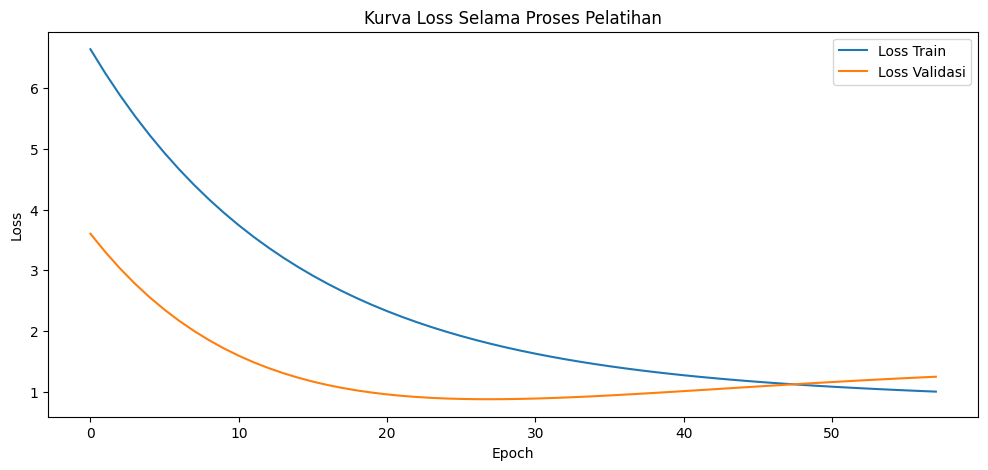

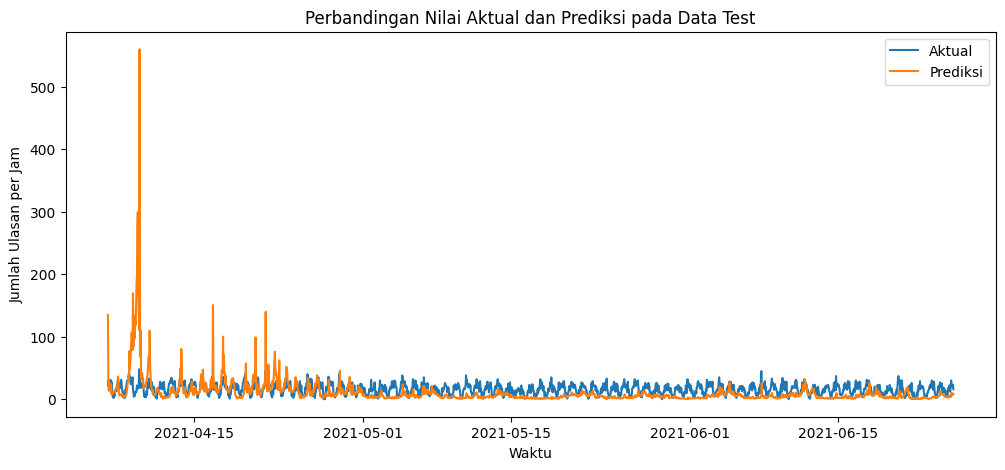

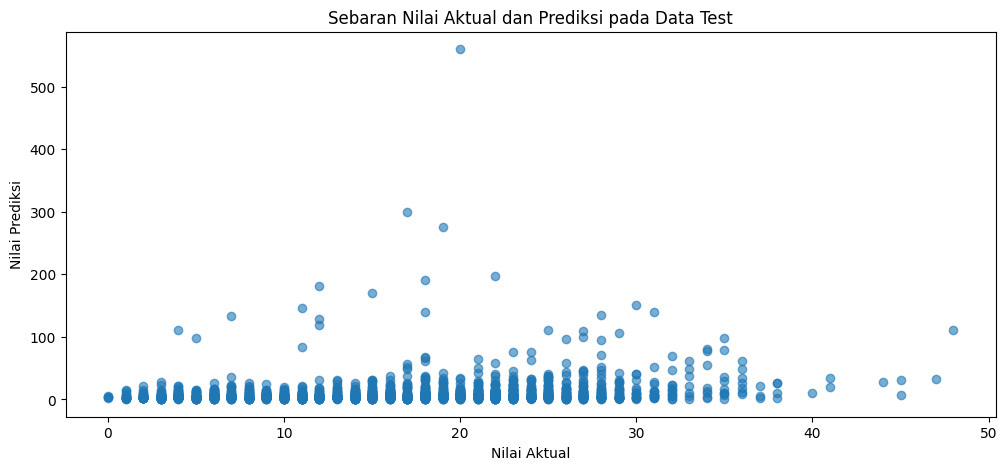


Contoh 20 baris terakhir hasil prediksi:


,ds,y,prediksi,error
12812,2021-06-25 04:00:00,11.0,3.807631,7.192369
12813,2021-06-25 05:00:00,14.0,3.950574,10.049426
12814,2021-06-25 06:00:00,7.0,3.728108,3.271892
12815,2021-06-25 07:00:00,8.0,4.035775,3.964225
12816,2021-06-25 08:00:00,4.0,3.240863,0.759137
12817,2021-06-25 09:00:00,5.0,3.969231,1.030769
12818,2021-06-25 10:00:00,6.0,3.403421,2.596579
12819,2021-06-25 11:00:00,18.0,2.778109,15.221891
12820,2021-06-25 12:00:00,14.0,4.827615,9.172385
12821,2021-06-25 13:00:00,16.0,3.010870,12.989130



Model berhasil disimpan: /content/model_backprop_manual.pkl

Model berhasil dimuat ulang.
ID terpilih: 0
Jumlah fitur: 9

Hasil pengujian deployment sederhana:


,hour_sin,hour_cos,dow_sin,dow_cos,lag_1,lag_24,lag_168,roll_mean_24,roll_std_24,aktual,prediksi,selisih,absolut_error
10907,-0.965926,0.258819,0.781831,0.623490,46.0,39.0,25.0,21.250000,11.128694,28.0,134.668267,-106.668267,106.668267
11869,-0.707107,0.707107,-0.781831,0.623490,17.0,12.0,16.0,10.583333,6.762535,10.0,1.708843,8.291157,8.291157
12831,-0.258819,0.965926,-0.433884,-0.900969,23.0,19.0,23.0,15.208333,6.795006,16.0,8.510938,7.489062,7.489062


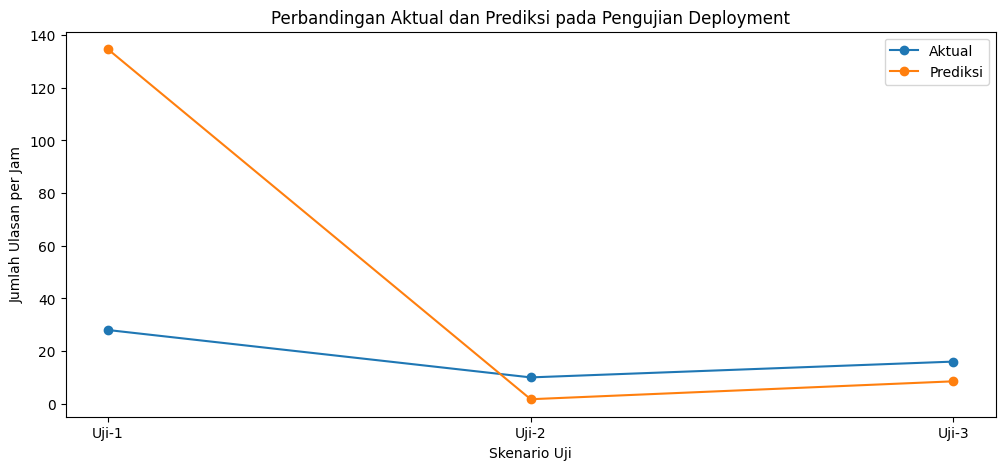


INTERPRETASI SINGKAT:
- Kurva loss digunakan untuk membaca kestabilan proses pelatihan.
- Jika loss train turun dan loss validasi tetap terkendali, model cenderung stabil.
- Jika prediksi mengikuti pola aktual, model telah menangkap pola temporal dasar.
- Keberhasilan memuat ulang model menunjukkan bahwa model siap untuk deployment dasar.

RINGKASAN:
1. Dataset berhasil dimuat dan divalidasi.
2. Model berhasil dilatih dengan backpropagation manual.
3. Model berhasil dievaluasi, disimpan, dimuat ulang, dan diuji secara sederhana.


In [3]:
# ============================================================
# JUDUL PROGRAM
# IMPLEMENTASI BACKPROPAGATION MANUAL DENGAN SATU HIDDEN LAYER
# UNTUK PREDIKSI JUMLAH ULASAN PER JAM PADA DATA TIME-SERIES
# DENGAN VALIDASI DATA, PENYIMPANAN MODEL, DAN UJI DEPLOYMENT
# ============================================================

# ============================================================
# DESKRIPSI SINGKAT
# Program ini bertujuan membangun model prediksi jumlah ulasan
# per jam menggunakan jaringan saraf tiruan dengan satu hidden
# layer dan proses backpropagation manual.
#
# Alur analisis disusun secara logis sebagai berikut:
# 1. Memuat dataset dari sumber resmi dalam bentuk berkas ZIP
# 2. Memeriksa isi arsip dan membaca file CSV
# 3. Memvalidasi struktur data
# 4. Melakukan praproses data
# 5. Menyusun fitur berbasis waktu dan histori
# 6. Membagi data menjadi train, validasi, dan test
# 7. Menormalisasi fitur
# 8. Melatih model dengan backpropagation manual
# 9. Mengevaluasi hasil pelatihan
# 10. Menyimpan dan memuat ulang model
# 11. Melakukan pengujian deployment sederhana
#
# Catatan metodologis:
# Dataset diperlakukan sebagai masalah time-series regression,
# sehingga target yang diprediksi adalah jumlah ulasan per jam.
# ============================================================

# ------------------------------------------------------------
# 0. IMPORT LIBRARY
# ------------------------------------------------------------
import os
import io
import zipfile
import pickle
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. INISIALISASI AWAL
# ------------------------------------------------------------
# Penetapan seed dilakukan untuk menjaga konsistensi hasil.
np.random.seed(42)
plt.rcParams["figure.figsize"] = (12, 5)

# ------------------------------------------------------------
# 2. MEMUAT DATASET DARI BERKAS ZIP RESMI
# ------------------------------------------------------------
# Pendekatan ini lebih aman dibanding langsung membaca CSV dari
# URL yang belum tentu tersedia.
url_zip = "https://archive.ics.uci.edu/static/public/1276/amazon%2Bproduct%2Band%2Bgoogle%2Blocations%2Breviews.zip"

print("Mengunduh dataset dari sumber resmi...")
response = requests.get(url_zip, timeout=120)
response.raise_for_status()

zip_buffer = io.BytesIO(response.content)

with zipfile.ZipFile(zip_buffer, "r") as zf:
    daftar_file = zf.namelist()
    print("\nDaftar file dalam arsip ZIP:")
    print(daftar_file)

    # Mencari file CSV secara otomatis
    kandidat_csv = [f for f in daftar_file if f.lower().endswith(".csv")]
    if len(kandidat_csv) == 0:
        raise ValueError("Tidak ditemukan file CSV di dalam arsip ZIP.")

    # Jika terdapat lebih dari satu file CSV, program memilih file pertama
    nama_csv = kandidat_csv[0]
    print(f"\nFile CSV yang digunakan: {nama_csv}")

    with zf.open(nama_csv) as f:
        df = pd.read_csv(f)

print("\nDataset berhasil dimuat.")
print("Ukuran dataset awal:", df.shape)
print("\nKolom dataset:")
print(df.columns.tolist())
print("\nContoh lima baris pertama:")
display(df.head())

# ------------------------------------------------------------
# 3. VALIDASI STRUKTUR DATA
# ------------------------------------------------------------
# Validasi dilakukan agar proses analisis tidak berjalan dengan
# asumsi struktur data yang salah.
kolom_wajib = ["ds", "y", "unique_id"]
for kolom in kolom_wajib:
    if kolom not in df.columns:
        raise ValueError(
            f"Kolom '{kolom}' tidak ditemukan. "
            f"Kolom tersedia: {df.columns.tolist()}"
        )

# ------------------------------------------------------------
# 4. PRAPROSES DATA
# ------------------------------------------------------------
# Konversi tipe data dilakukan agar variabel dapat diproses
# sesuai tujuan analisis.
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df["unique_id"] = df["unique_id"].astype(str)

# Penghapusan baris yang tidak valid
df = df.dropna(subset=["ds", "y", "unique_id"]).copy()
df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

print("\nJumlah data setelah praproses:", len(df))
print("Jumlah kategori unique_id:", df["unique_id"].nunique())

# ------------------------------------------------------------
# 5. PEMILIHAN SATU SERI WAKTU
# ------------------------------------------------------------
# Untuk menjaga efisiensi komputasi dan kejelasan interpretasi,
# dipilih satu kategori dengan jumlah observasi terbanyak.
id_terpilih = df["unique_id"].value_counts().idxmax()
ts = df[df["unique_id"] == id_terpilih].copy().sort_values("ds").reset_index(drop=True)

print(f"\nID kategori/lokasi terpilih: {id_terpilih}")
print(f"Jumlah observasi pada ID terpilih: {len(ts)}")

# ------------------------------------------------------------
# 6. VISUALISASI AWAL DATA
# ------------------------------------------------------------
plt.figure()
plt.plot(ts["ds"], ts["y"])
plt.title("Jumlah Ulasan per Jam pada Kategori/Lokasi Terpilih")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Ulasan")
plt.show()

plt.figure()
plt.hist(ts["y"], bins=40)
plt.title("Distribusi Target Awal")
plt.xlabel("Jumlah Ulasan per Jam")
plt.ylabel("Frekuensi")
plt.show()

# ------------------------------------------------------------
# 7. REKAYASA FITUR
# ------------------------------------------------------------
# Karena data bersifat time-series, fitur waktu dan histori
# digunakan agar model dapat mempelajari pola temporal.
ts["hour"] = ts["ds"].dt.hour
ts["dayofweek"] = ts["ds"].dt.dayofweek

# Encoding siklik untuk fitur waktu
ts["hour_sin"] = np.sin(2 * np.pi * ts["hour"] / 24)
ts["hour_cos"] = np.cos(2 * np.pi * ts["hour"] / 24)
ts["dow_sin"] = np.sin(2 * np.pi * ts["dayofweek"] / 7)
ts["dow_cos"] = np.cos(2 * np.pi * ts["dayofweek"] / 7)

# Fitur lag untuk menangkap pengaruh masa lalu
ts["lag_1"] = ts["y"].shift(1)
ts["lag_24"] = ts["y"].shift(24)
ts["lag_168"] = ts["y"].shift(168)

# Statistik rolling untuk merangkum kecenderungan lokal
ts["roll_mean_24"] = ts["y"].shift(1).rolling(24).mean()
ts["roll_std_24"] = ts["y"].shift(1).rolling(24).std()

# Transformasi log untuk mengurangi pengaruh lonjakan ekstrem
ts["y_log"] = np.log1p(ts["y"])

# Penghapusan baris kosong akibat proses lag dan rolling
ts = ts.dropna().reset_index(drop=True)

fitur = [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "lag_1", "lag_24", "lag_168",
    "roll_mean_24", "roll_std_24"
]

X = ts[fitur].copy()
y = ts["y_log"].values.reshape(-1, 1)

print("\nUkuran data setelah rekayasa fitur:")
print("Jumlah sampel :", X.shape[0])
print("Jumlah fitur  :", X.shape[1])

# ------------------------------------------------------------
# 8. PEMBAGIAN DATA BERDASARKAN URUTAN WAKTU
# ------------------------------------------------------------
# Pembagian tidak dilakukan secara acak agar tidak terjadi
# kebocoran informasi dari masa depan ke masa lalu.
n = len(ts)
batas_train = int(n * 0.70)
batas_validasi = int(n * 0.85)

X_train = X.iloc[:batas_train].copy()
X_val = X.iloc[batas_train:batas_validasi].copy()
X_test = X.iloc[batas_validasi:].copy()

y_train = y[:batas_train]
y_val = y[batas_train:batas_validasi]
y_test = y[batas_validasi:]

data_test = ts.iloc[batas_validasi:].copy()

# ------------------------------------------------------------
# 9. NORMALISASI FITUR
# ------------------------------------------------------------
# Standardisasi hanya dipelajari dari data latih agar tidak
# terjadi data leakage.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# ------------------------------------------------------------
# 10. DEFINISI MODEL JARINGAN SARAF TIRUAN
# ------------------------------------------------------------
input_dim = X_train_sc.shape[1]
hidden_dim = 16
output_dim = 1

# Inisialisasi parameter
W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(1 / hidden_dim)
b2 = np.zeros((1, output_dim))

# Hyperparameter
learning_rate = 0.003
epochs = 300
lambda_l2 = 1e-4
patience = 30

def relu(z):
    return np.maximum(0, z)

def relu_turunan(z):
    return (z > 0).astype(float)

def forward(X_input, W1, b1, W2, b2):
    z1 = X_input @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    y_pred = z2
    return z1, a1, z2, y_pred

def hitung_loss(y_asli, y_pred, W1, W2, lambda_l2=0.0):
    mse = np.mean((y_asli - y_pred) ** 2)
    regulasi = lambda_l2 * (np.sum(W1**2) + np.sum(W2**2))
    return mse + regulasi

# ------------------------------------------------------------
# 11. PELATIHAN MODEL DENGAN BACKPROPAGATION MANUAL
# ------------------------------------------------------------
loss_train_hist = []
loss_val_hist = []

best_val_loss = np.inf
best_params = None
counter_sabar = 0

for epoch in range(epochs):
    # Forward pass pada data latih
    z1, a1, z2, y_pred_train = forward(X_train_sc, W1, b1, W2, b2)

    # Menghitung loss data latih
    loss_train = hitung_loss(y_train, y_pred_train, W1, W2, lambda_l2)

    # Backward pass
    m = len(X_train_sc)
    dY = (2 / m) * (y_pred_train - y_train)

    dW2 = a1.T @ dY + 2 * lambda_l2 * W2
    db2 = np.sum(dY, axis=0, keepdims=True)

    dA1 = dY @ W2.T
    dZ1 = dA1 * relu_turunan(z1)

    dW1 = X_train_sc.T @ dZ1 + 2 * lambda_l2 * W1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Pembaruan parameter
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # Evaluasi validasi
    _, _, _, y_pred_val = forward(X_val_sc, W1, b1, W2, b2)
    loss_val = hitung_loss(y_val, y_pred_val, W1, W2, lambda_l2)

    loss_train_hist.append(loss_train)
    loss_val_hist.append(loss_val)

    # Early stopping
    if loss_val < best_val_loss:
        best_val_loss = loss_val
        best_params = (W1.copy(), b1.copy(), W2.copy(), b2.copy())
        counter_sabar = 0
    else:
        counter_sabar += 1
        if counter_sabar >= patience:
            print(f"\nEarly stopping aktif pada epoch ke-{epoch+1}")
            break

# Menggunakan parameter terbaik
W1, b1, W2, b2 = best_params

# ------------------------------------------------------------
# 12. PREDIKSI PADA DATA TRAIN, VALIDASI, DAN TEST
# ------------------------------------------------------------
_, _, _, pred_train_log = forward(X_train_sc, W1, b1, W2, b2)
_, _, _, pred_val_log = forward(X_val_sc, W1, b1, W2, b2)
_, _, _, pred_test_log = forward(X_test_sc, W1, b1, W2, b2)

pred_train = np.expm1(pred_train_log).ravel()
pred_val = np.expm1(pred_val_log).ravel()
pred_test = np.expm1(pred_test_log).ravel()

true_train = np.expm1(y_train).ravel()
true_val = np.expm1(y_val).ravel()
true_test = np.expm1(y_test).ravel()

# ------------------------------------------------------------
# 13. EVALUASI MODEL
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    penyebut = (np.abs(y_true) + np.abs(y_pred)) / 2
    penyebut = np.where(penyebut == 0, 1e-8, penyebut)
    return np.mean(np.abs(y_true - y_pred) / penyebut) * 100

tabel_evaluasi = pd.DataFrame({
    "Data": ["Train", "Validasi", "Test"],
    "MAE": [
        mean_absolute_error(true_train, pred_train),
        mean_absolute_error(true_val, pred_val),
        mean_absolute_error(true_test, pred_test)
    ],
    "RMSE": [
        rmse(true_train, pred_train),
        rmse(true_val, pred_val),
        rmse(true_test, pred_test)
    ],
    "sMAPE (%)": [
        smape(true_train, pred_train),
        smape(true_val, pred_val),
        smape(true_test, pred_test)
    ],
    "R2": [
        r2_score(true_train, pred_train),
        r2_score(true_val, pred_val),
        r2_score(true_test, pred_test)
    ]
})

print("\nTabel evaluasi model:")
display(tabel_evaluasi)

# ------------------------------------------------------------
# 14. VISUALISASI HASIL PELATIHAN
# ------------------------------------------------------------
plt.figure()
plt.plot(loss_train_hist, label="Loss Train")
plt.plot(loss_val_hist, label="Loss Validasi")
plt.title("Kurva Loss Selama Proses Pelatihan")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

hasil_uji = data_test[["ds", "y"]].copy()
hasil_uji["prediksi"] = pred_test
hasil_uji["error"] = hasil_uji["y"] - hasil_uji["prediksi"]

plt.figure()
plt.plot(hasil_uji["ds"], hasil_uji["y"], label="Aktual")
plt.plot(hasil_uji["ds"], hasil_uji["prediksi"], label="Prediksi")
plt.title("Perbandingan Nilai Aktual dan Prediksi pada Data Test")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Ulasan per Jam")
plt.legend()
plt.show()

plt.figure()
plt.scatter(true_test, pred_test, alpha=0.6)
plt.title("Sebaran Nilai Aktual dan Prediksi pada Data Test")
plt.xlabel("Nilai Aktual")
plt.ylabel("Nilai Prediksi")
plt.show()

print("\nContoh 20 baris terakhir hasil prediksi:")
display(hasil_uji.tail(20))

# ------------------------------------------------------------
# 15. MENYIMPAN MODEL
# ------------------------------------------------------------
# Penyimpanan model dilakukan agar hasil pelatihan dapat
# digunakan kembali tanpa pelatihan ulang.
model_data = {
    "W1": W1,
    "b1": b1,
    "W2": W2,
    "b2": b2,
    "scaler": scaler,
    "fitur": fitur,
    "id_terpilih": id_terpilih,
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "output_dim": output_dim
}

nama_file_model = "model_backprop_manual.pkl"
with open(nama_file_model, "wb") as f:
    pickle.dump(model_data, f)

print(f"\nModel berhasil disimpan: {os.path.abspath(nama_file_model)}")

# ------------------------------------------------------------
# 16. MEMUAT ULANG MODEL
# ------------------------------------------------------------
with open(nama_file_model, "rb") as f:
    model_tersimpan = pickle.load(f)

print("\nModel berhasil dimuat ulang.")
print("ID terpilih:", model_tersimpan["id_terpilih"])
print("Jumlah fitur:", len(model_tersimpan["fitur"]))

# ------------------------------------------------------------
# 17. FUNGSI PREDIKSI DATA BARU
# ------------------------------------------------------------
def prediksi_data_baru(data_baru, model):
    if isinstance(data_baru, dict):
        data_baru = pd.DataFrame([data_baru])

    X_baru = data_baru[model["fitur"]].copy()
    X_baru_sc = model["scaler"].transform(X_baru)

    z1 = X_baru_sc @ model["W1"] + model["b1"]
    a1 = relu(z1)
    z2 = a1 @ model["W2"] + model["b2"]
    y_pred_log = z2

    return np.expm1(y_pred_log).ravel()

# ------------------------------------------------------------
# 18. PENGUJIAN DEPLOYMENT SEDERHANA
# ------------------------------------------------------------
# Pengujian dilakukan dengan tiga contoh data dari himpunan test
# untuk memastikan model yang disimpan dapat dipakai kembali.
idx_uji_1 = 0
idx_uji_2 = len(X_test) // 2
idx_uji_3 = len(X_test) - 1

sampel_deployment = X_test.iloc[[idx_uji_1, idx_uji_2, idx_uji_3]].copy()
aktual_deployment = np.expm1(y_test[[idx_uji_1, idx_uji_2, idx_uji_3]].ravel())
prediksi_deployment = prediksi_data_baru(sampel_deployment, model_tersimpan)

hasil_deployment = sampel_deployment.copy()
hasil_deployment["aktual"] = aktual_deployment
hasil_deployment["prediksi"] = prediksi_deployment
hasil_deployment["selisih"] = hasil_deployment["aktual"] - hasil_deployment["prediksi"]
hasil_deployment["absolut_error"] = np.abs(hasil_deployment["selisih"])

print("\nHasil pengujian deployment sederhana:")
display(hasil_deployment)

plt.figure()
x_axis = np.arange(len(hasil_deployment))
plt.plot(x_axis, hasil_deployment["aktual"], marker="o", label="Aktual")
plt.plot(x_axis, hasil_deployment["prediksi"], marker="o", label="Prediksi")
plt.title("Perbandingan Aktual dan Prediksi pada Pengujian Deployment")
plt.xlabel("Skenario Uji")
plt.ylabel("Jumlah Ulasan per Jam")
plt.xticks(x_axis, ["Uji-1", "Uji-2", "Uji-3"])
plt.legend()
plt.show()

# ------------------------------------------------------------
# 19. INTERPRETASI SINGKAT
# ------------------------------------------------------------
print("\nINTERPRETASI SINGKAT:")
print("- Kurva loss digunakan untuk membaca kestabilan proses pelatihan.")
print("- Jika loss train turun dan loss validasi tetap terkendali, model cenderung stabil.")
print("- Jika prediksi mengikuti pola aktual, model telah menangkap pola temporal dasar.")
print("- Keberhasilan memuat ulang model menunjukkan bahwa model siap untuk deployment dasar.")

print("\nRINGKASAN:")
print("1. Dataset berhasil dimuat dan divalidasi.")
print("2. Model berhasil dilatih dengan backpropagation manual.")
print("3. Model berhasil dievaluasi, disimpan, dimuat ulang, dan diuji secara sederhana.")